In [1]:
import util
import processUtil

from skimage import filters, morphology, measure, exposure
from skimage.segmentation import find_boundaries
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import joblib
import pandas as pd

# Get data

In [2]:
file_path = "processed_data/aliveData.joblib"

if os.path.exists(file_path):
    data = joblib.load(file_path)
else:
    data = util.getAliveData()
    joblib.dump(data, file_path)

# Get Mask (Segmentation)

In [3]:
# get masks and corrects for all alive data
# masks_corrected: index 0 = mask, index 1 = corrected
file_path = "processed_data/maskCorrect.joblib"

if os.path.exists(file_path):
    masks_corrected = joblib.load(file_path)
else:
    masks_corrected = []
    for i in range(len(data)):
        masks_corrected.append(processUtil.getSegments(data[i]))
    joblib.dump(masks_corrected, file_path)

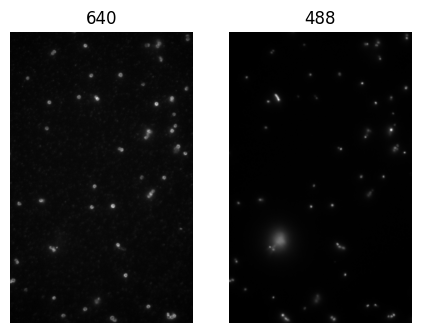

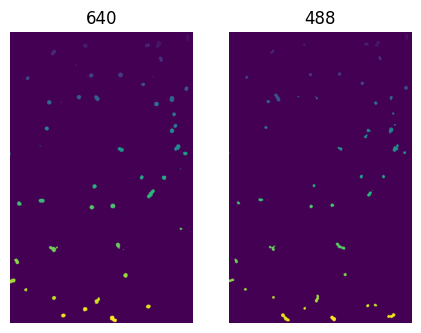

In [4]:
img_index = 0 # 0-133
util.printImg(data[img_index], "gray")
util.printMask(masks_corrected[img_index])

# Get Morphological Features

In [5]:
# get stats of each bateria for each img data
# stats: label, area, x, y, major_length, minor_length
file_path = "processed_data/maskSegmentStat.joblib"

if os.path.exists(file_path):
    stats = joblib.load(file_path)
else:
    stats = []
    for i in range(len(data)):
        stats.append(processUtil.getStats(masks_corrected[i], data[i]))
    joblib.dump(stats, file_path)

Image: pos_43


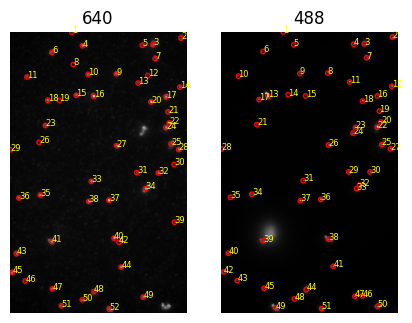

In [6]:
print(f"Image: {data[img_index][3]}")
util.printRegion(data[img_index], stats[img_index], map="gray")

In [7]:
print(stats[img_index][1])

    label   area           x           y  major_length  minor_length  \
0       1   12.0  149.750000    0.583333      6.151479      2.526169   
1       2   80.0  415.225000   13.037500     14.832377      7.082944   
2       3   97.0  346.927835   29.391753     16.168577      8.048636   
3       4   59.0  320.966102   30.271186     11.144337      6.782221   
4       5   17.0  175.470588   31.647059      4.957955      4.338609   
5       6   49.0  100.897959   48.102041     11.793957      5.799191   
6       7   51.0  352.568627   63.196078     10.483918      6.341963   
7       8   49.0  258.163265  100.428571      8.495239      7.310626   
8       9   41.0  190.000000  101.756098      7.231368      7.165254   
9      10   37.0   41.000000  108.000000      6.833938      6.833938   
10     11   47.0  311.170213  122.021277      8.066212      7.391592   
11     12   61.0  413.557377  132.688525      9.175999      8.463965   
12     13  146.0  112.705479  155.520548     21.926708      8.64

# Segmentation Comparison

In [8]:
file_path = "processed_data/compare.joblib"

if os.path.exists(file_path):
    compared = list(joblib.load(file_path))
else:
    compared = []
    for i in range(len(data)):
        shared, only_640, only_488, df_640_labeled, df_488_labeled, combined = processUtil.match_two_channels_greedy(
            df_a=stats[i][0],
            df_b=stats[i][1],
            tolerance=3,
            area_ratio_warning=3.0,
            channel_a_name="640",
            channel_b_name="488"
        )
        compared.append({"shared":shared, "only_640":only_640, "only_488":only_488, "df_640_labeled":df_640_labeled, "df_488_labeled":df_488_labeled, "combined":combined})
    joblib.dump(compared, file_path)

Image: pos_43


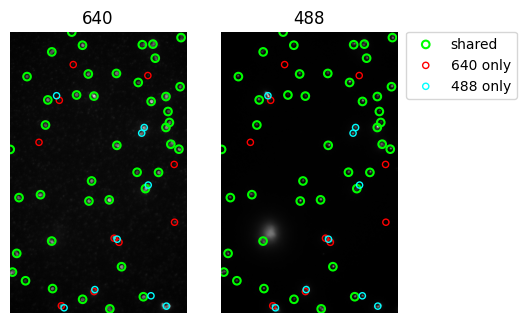

In [9]:
print(f"Image: {data[img_index][3]}")
util.printLabel(data[img_index], compared[img_index], map="gray")

Todo:
- count num of bateria:
```python
print(f"Segmentation complete.")
print(f"Masks shape: {masks.shape}")
print("Unique mask values:", np.unique(masks))
print("Number of objects:", len(np.unique(masks)) - 1)
```

Image: pos_54


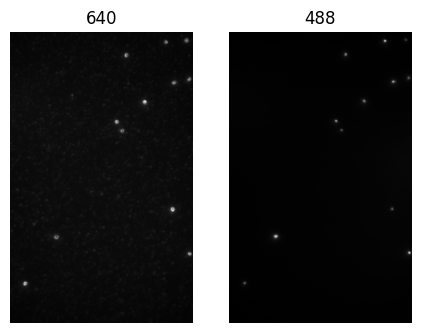

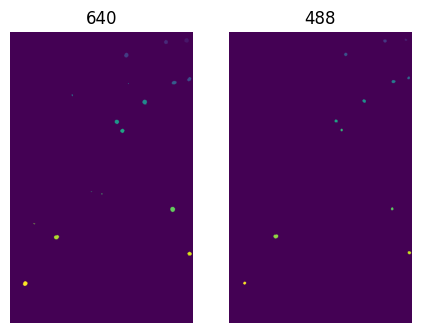

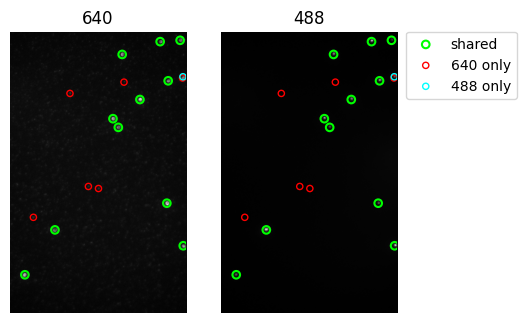

In [10]:
# testing
img_index = 11# 0-133
print(f"Image: {data[img_index][3]}")
util.printImg(data[img_index], "gray")
util.printMask(masks_corrected[img_index])
util.printLabel(data[img_index], compared[img_index], map="gray")

# Non-local Trainable Feature Extraction

In [11]:
processor = processUtil.extract_unified_features(compared[img_index]["combined"])

In [12]:
print(processor)

    in_640  in_488  major_length  minor_length  length_ratio  eccentricity  \
0     True    True      9.269861      8.192253  1.131080e+00      0.467259   
1     True    True      8.462722      7.413934  1.211825e+00      0.454190   
2     True    True      9.454066      8.506501  1.125854e+00      0.448881   
3     True    True      8.963878      8.303159  1.083091e+00      0.380521   
4     True    True      7.972711      7.257948  1.119074e+00      0.419149   
5     True    True      9.516405      8.592426  1.100185e+00      0.387656   
6     True    True     11.742131      9.419408  1.246344e+00      0.596235   
7     True    True      8.809039      8.100665  1.090795e+00      0.391151   
8     True    True     10.482883      7.539172  1.385790e+00      0.685924   
9     True    True     10.058448      8.924720  1.141485e+00      0.458071   
10    True    True      9.062570      7.901991  1.147839e+00      0.490611   
11    True   False     10.936410      7.828633  1.396976e+00    

In [13]:
extracted_features = []
for i in range(len(data)):
    clean_features = processUtil.extract_unified_features(compared[i]["combined"])
    extracted_features.append(clean_features)

extracted_features_df = pd.concat(extracted_features, ignore_index=True)

In [14]:
len(extracted_features_df)

14337

In [15]:
extracted_features_df

,in_640,in_488,major_length,minor_length,length_ratio,eccentricity,solidity,mean_intensity,max_intensity
0,True,True,7.932236,3.163984,2.494972,0.916002,0.895238,9108.250000,14366.0
1,True,True,20.162198,8.675753,2.274799,0.887100,0.914155,7199.137755,9930.0
2,True,True,12.704223,9.766363,1.305316,0.589083,0.961737,13964.686700,33506.5
3,True,True,14.355160,8.165330,1.811344,0.817309,0.904172,10474.997141,18541.5
4,True,True,13.168991,7.591496,1.738530,0.817805,0.923443,8199.398110,16866.0
...,...,...,...,...,...,...,...,...,...
14332,False,True,11.485116,5.008069,2.293322,0.899923,0.914894,16468.232558,21657.0
14333,False,True,11.418205,4.034714,2.829991,0.935488,0.900000,21182.861111,24302.0
14334,False,True,22.486524,8.585041,2.619268,0.924251,0.810976,38500.180451,65535.0
14335,False,True,2.000000,2.000000,1.000000,0.000000,1.000000,22360.000000,23017.0


# Saving all data and Images

## Save Final Extracted Features

In [16]:
path = os.getcwd()
results_dir = os.path.join(path, "results")
os.makedirs(results_dir, exist_ok=True)

extracted_features_df.to_csv(os.path.join(results_dir, "extracted_features.csv"), index=False)

# Save Images

In [42]:
import os
import matplotlib.pyplot as plt

path = os.getcwd()
results_dir = os.path.join(path, "results")
os.makedirs(results_dir, exist_ok=True)

old_show = plt.show
plt.show = lambda *args, **kwargs: None

for i in range(len(data)):
    file_name = data[i][3]
    print(file_name)

    sample_dir = os.path.join(results_dir, file_name)
    print(sample_dir)
    os.makedirs(sample_dir, exist_ok=True)

    util.printLabel(data[i], compared[i], map="gray")
    plt.savefig(os.path.join(sample_dir, "Label.png"), dpi=300, bbox_inches="tight")
    plt.close()

    util.printRegion(data[i], stats[i], map="gray")
    plt.savefig(os.path.join(sample_dir, "Region.png"), dpi=300, bbox_inches="tight")
    plt.close()

    util.printMask(masks_corrected[i])
    plt.savefig(os.path.join(sample_dir, "Mask.png"), dpi=300, bbox_inches="tight")
    plt.close()

    compared[i]['df_640_labeled'].to_csv(os.path.join(sample_dir, "df_640_labeled.csv"), index=False)
    compared[i]['df_488_labeled'].to_csv(os.path.join(sample_dir, "df_488_labeled.csv"), index=False)
    compared[i]['combined'].to_csv(os.path.join(sample_dir, "combined_640_488_classification.csv"), index=False)

plt.show = old_show

pos_43
C:\Users\HP\Desktop\Warwick\Hackathon\BioImage\1-pipeline\results\pos_43
pos_44
C:\Users\HP\Desktop\Warwick\Hackathon\BioImage\1-pipeline\results\pos_44
pos_45
C:\Users\HP\Desktop\Warwick\Hackathon\BioImage\1-pipeline\results\pos_45
pos_46
C:\Users\HP\Desktop\Warwick\Hackathon\BioImage\1-pipeline\results\pos_46
pos_47
C:\Users\HP\Desktop\Warwick\Hackathon\BioImage\1-pipeline\results\pos_47
pos_48
C:\Users\HP\Desktop\Warwick\Hackathon\BioImage\1-pipeline\results\pos_48
pos_49
C:\Users\HP\Desktop\Warwick\Hackathon\BioImage\1-pipeline\results\pos_49
pos_50
C:\Users\HP\Desktop\Warwick\Hackathon\BioImage\1-pipeline\results\pos_50
pos_51
C:\Users\HP\Desktop\Warwick\Hackathon\BioImage\1-pipeline\results\pos_51
pos_52
C:\Users\HP\Desktop\Warwick\Hackathon\BioImage\1-pipeline\results\pos_52
pos_53
C:\Users\HP\Desktop\Warwick\Hackathon\BioImage\1-pipeline\results\pos_53
pos_54
C:\Users\HP\Desktop\Warwick\Hackathon\BioImage\1-pipeline\results\pos_54
pos_55
C:\Users\HP\Desktop\Warwick\Hacka